# Example 2: Gaussian Hypothesis Testing

## Statistical framework

- **Prior**: $\theta \sim \mathcal{N}(0, \sigma_0^2)$  
- **Model**: $X = (X_1, \ldots, X_n) \sim \mathcal{N}(\theta, 1)$ (given $\theta$, the $X_i$ are i.i.d. $\mathcal{N}(\theta, 1)$)  
- **Bob's hypothesis**: $H_0^B : \theta \leq c_B$  
- **Eve's hypothesis**: $H_0^E : T(X) \leq c_E$, where $T(X) = \bar{X}$ (mean) or $T(X) = \max X$

# Functions

### Plots

In [78]:
import os

# Set cwd to repo root (parent of notebooks/ when running from notebook)
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    os.chdir(os.path.dirname(_cwd))

os.makedirs("figures/paper", exist_ok=True)
os.makedirs("figures/supplementary", exist_ok=True)


def plot_sigma_paper(RA1, RA2, RA3s, RA4s, RA5s, sigmas, yticks=None, ylim=None, save_name=None):
    plt.figure(figsize=(8, 5))
    plt.axhline(RA1, color='grey', linestyle='--', label='(i) Full = (ii) Null')
    plt.axhline(RA2, color='grey', linestyle='--')#, label='(ii) Null')
    plt.plot(sigmas, RA3s, label='(iii) Noisy full', color = "black", linestyle='-')
    plt.plot(sigmas, RA4s, label='(iv) Noisy mean', color = "black", linestyle='-.')
    plt.plot(sigmas, RA5s, label='(v) Noisy median', color = "black", linestyle=':')
    plt.xscale('log')
    plt.xlabel('$\sigma$', fontsize=14)
    plt.ylabel('$R_A$', fontsize=14)
    # plt.title('Risk vs Noise Level for Different Release Mechanisms')
    if yticks is not None:
        plt.yticks(yticks)
    if ylim is not None:
        plt.ylim(ylim)
    if yticks is not None:
        plt.yticks(yticks)
    
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.legend()

    plt.show()
    
def plot_tau_paper(RA1, RA2, RA6s, taus, yticks=None, ylim=None, save_name=None):
    plt.figure(figsize=(8, 5))
    plt.axhline(RA1, color='grey', linestyle='--', label='(i) Full = (ii) Null')
    plt.axhline(RA2, color='grey', linestyle='--')#, label='(ii) Null')
    plt.plot(taus, RA6s, label='(vi) One-bit', color = "black", linestyle='-')
    plt.xlabel('$\\tau$', fontsize=14)
    plt.ylabel('$R_A$', fontsize=14)
    if yticks is not None:
        plt.yticks(yticks)
    if ylim is not None:
        plt.ylim(ylim)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.legend()
    plt.show()
from matplotlib import pyplot as plt

def plot_sigma_supplementary(RB1 = None, RE1 = None, RA1 = None,
               RB2 = None, RE2 = None, RA2 = None,
               RB3s = None, RE3s = None, RA3s = None,
               RB4s = None, RE4s = None, RA4s = None,
               RB5s = None, RE5s = None, RA5s = None, sigmas = None, save_name=None):
    """Plot risks vs noise level sigma for cases 1-5"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bob's risk
    if RB1 is not None and RB2 is not None:
        axes[0].axhline(RB1, color='gray', linestyle='-', label="(i) Full")
        axes[0].axhline(RB2, color='gray', linestyle='--', label="(ii) Null")
    if RB3s is not None:
        axes[0].plot(sigmas, RB3s, label="(iii) Noisy full", color="black")
    if RB4s is not None:
        axes[0].plot(sigmas, RB4s, label="(iv) Noisy mean", color="black", linestyle="-.")
    if RB5s is not None:
        axes[0].plot(sigmas, RB5s, label="(v) Noisy median", color="black", linestyle=":")
    axes[0].set_xscale('log')
    axes[0].set_xlabel("$\sigma$", fontsize=12)
    axes[0].set_ylabel("$R_B$", fontsize=12)
    axes[0].set_title("Bob's risk $R_B$", fontsize=12)
    axes[0].legend()
    # axes[0].grid(True, alpha=0.3)
    
    # Eve's risk
    if RE1 is not None and RE2 is not None:
        axes[1].axhline(RE1, color='gray', linestyle='-', label="(i) Full")
        axes[1].axhline(RE2, color='gray', linestyle='--', label="(ii) Null")
    if RE3s is not None:
        axes[1].plot(sigmas, RE3s, label="(iii) Noisy full", color="black")
    if RE4s is not None:
        axes[1].plot(sigmas, RE4s, label="(iv) Noisy mean", color="black", linestyle="-.")
    if RE5s is not None:
        axes[1].plot(sigmas, RE5s, label="(v) Noisy median", color="black", linestyle=":")
    axes[1].set_xscale('log')
    axes[1].set_xlabel("$\sigma$", fontsize=12)
    axes[1].set_ylabel("$R_E$", fontsize=12)
    axes[1].set_title("Eve's risk $R_E$", fontsize=12)
    axes[1].legend()
    # axes[1].grid(True, alpha=0.3)
    
    # Alice's risk
    if RA1 is not None and RA2 is not None:
        axes[2].axhline(RA1, color='gray', linestyle='--', label="(i) Full = (ii) Null")
        axes[2].axhline(RA2, color='gray', linestyle='--')# label="(ii) Null")
    if RA3s is not None:
        axes[2].plot(sigmas, RA3s, label="(iii) Noisy full", color="black")
    if RA4s is not None:
        axes[2].plot(sigmas, RA4s, label="(iv) Noisy mean", color="black", linestyle="-.")
    if RA5s is not None:
        axes[2].plot(sigmas, RA5s, label="(v) Noisy median", color="black", linestyle=":")
    axes[2].set_xscale('log')
    axes[2].set_xlabel("$\sigma$", fontsize=12)
    axes[2].set_ylabel("$R_A$", fontsize=12)
    axes[2].set_title("Alice's risk $R_A$", fontsize=12)
    axes[2].legend()
    if save_name is not None:   
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    # axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_tau_supplementary(RB1 = None, RE1 = None, RA1 = None,
             RB2 = None, RE2 = None, RA2 = None,
             RB6s = None, RE6s = None, RA6s = None, taus = None,
             save_name=None):
    """Plot risks vs threshold tau for cases 1, 2, and 6"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bob's risk
    if RB1 is not None and RB2 is not None:
        axes[0].axhline(RB1, color='gray', linestyle='-', label="(i) Full")
        axes[0].axhline(RB2, color='gray', linestyle='--', label="(ii) Null")
    if RB6s is not None:
        axes[0].plot(taus, RB6s, label="(vi) One-bit", color="black")
    axes[0].set_xlabel("$\\tau$", fontsize=12)
    axes[0].set_ylabel("$R_B$", fontsize=12)
    axes[0].set_title("Bob's risk $R_B$", fontsize=12)
    axes[0].legend()
    # axes[0].grid(True, alpha=0.3)
    
    # Eve's risk
    if RE1 is not None and RE2 is not None:
        axes[1].axhline(RE1, color='gray', linestyle='-', label="(i) Full")
        axes[1].axhline(RE2, color='gray', linestyle='--', label="(ii) Null ")
    if RE6s is not None:
        axes[1].plot(taus, RE6s, label="(vi) One-bit", color="black")
    axes[1].set_xlabel("$\\tau$", fontsize=12)
    axes[1].set_ylabel("$R_E$", fontsize=12)
    axes[1].set_title("Eve's risk $R_E$", fontsize=12)
    axes[1].legend()
    # axes[1].grid(True, alpha=0.3)
    
    # Alice's risk
    if RA1 is not None and RA2 is not None:
        axes[2].axhline(RA1, color='gray', linestyle='--', label="(i) Full = (ii) Null")
        axes[2].axhline(RA2, color='gray', linestyle='--')#, label="(ii) Null release")
    if RA6s is not None:
        axes[2].plot(taus, RA6s, label="(vi) One-bit", color="black")
    axes[2].set_xlabel("$\\tau$", fontsize=12)
    axes[2].set_ylabel("$R_A$", fontsize=12)
    axes[2].set_title("Alice's risk $R_A$", fontsize=12)
    axes[2].legend()
    # axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()


### Utils

In [79]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.special import erf

# =========================================================
# Normal CDF / SF + Bayes 0-1 risk
# =========================================================
@jit
def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / jnp.sqrt(2.0)))

@jit
def norm_sf(x):
    return 0.5 * (1.0 - erf(x / jnp.sqrt(2.0)))

@jit
def bayes01_risk(p):
    return jnp.minimum(p, 1.0 - p)

# =========================================================
# Global GH nodes/weights
# =========================================================
xs_GH = None
ws_GH = None

def init_gauss_hermite(gh_deg: int):
    """
    Initialise les nœuds et poids Gauss-Hermite globaux.
    À appeler une fois au début.

    Notes de robustesse:
    - `numpy.polynomial.hermite.hermgauss` peut devenir numériquement instable
      à grand degré (poids infinis/NaN).
    - On borne le degré et on vérifie la finitude des noeuds/poids.
    """
    global xs_GH, ws_GH

    # Valeur robuste par défaut pour ce notebook; >256 est souvent instable
    # dans certaines versions de NumPy.
    deg = int(np.clip(int(gh_deg), 8, 256))

    xs, ws = np.polynomial.hermite.hermgauss(deg)
    xs = np.asarray(xs, dtype=np.float64)
    ws = np.asarray(ws, dtype=np.float64)

    if (not np.all(np.isfinite(xs))) or (not np.all(np.isfinite(ws))) or float(ws.sum()) == 0.0:
        raise ValueError(
            f"Invalid Gauss-Hermite nodes/weights for degree={deg}. "
            "Try a smaller degree (e.g. 120-220)."
        )

    xs_GH = jnp.asarray(xs)
    ws_GH = jnp.asarray(ws)

# =========================================================
# Generic GH expectation for Z ~ N(0,1)
# =========================================================
def make_gauss_hermite_expectation():
    """
    Factory qui construit une fonction:
      gh_expect(f) ≈ E_Z[f(Z)], Z~N(0,1)

    - Utilise xs_GH, ws_GH globaux.
    - f doit accepter Z avec shape (deg,) et retourner (deg,) ou (deg, ...)
    - NE PAS JIT cette fonction (elle prend une fonction en argument)
    """
    global xs_GH, ws_GH
    if xs_GH is None or ws_GH is None:
        raise ValueError("Call init_gauss_hermite(deg) before using GH expectation.")

    z = jnp.sqrt(2.0) * xs_GH                  # (deg,)
    w = ws_GH / jnp.sqrt(jnp.pi)               # (deg,)

    def gh_expect(f):
        """Calcule E[f(Z)] avec Z~N(0,1)"""
        vals = f(z)  # shape (deg,) ou (deg, ...)
        return jnp.tensordot(w, vals, axes=(0, 0))  # -> shape () ou (...)

    return gh_expect


def make_E_Phi_power_GH(gh_expect):
    """Vectorisé sur m (peut être scalaire ou array)"""
    @jit
    def E_Phi_power_GH(m, v, n, cE):
        m = jnp.asarray(m)
        v = jnp.asarray(v)
        
        def integrand(z):
            z_b = z.reshape((-1,) + (1,) * m.ndim)
            theta = m + jnp.sqrt(v) * z_b
            return norm_cdf(cE - theta) ** n
        
        return gh_expect(integrand)
    
    return E_Phi_power_GH


### Releases

#### (i) Full release

In [80]:

# =========================================================
# Case 1 — Full release (JAX)
# =========================================================

def make_risks_case1_mean_jax(n, gh_expect):
    """
    Full release: Bob observe toute l'info (via barX).
    RE = 0 par convention.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam) -> (RA, RB, RE)
    """
    n = int(n)
    
    @jit
    def risks_case1_mean(sigma0, cB, cE, lam):
        sigma0 = jnp.asarray(sigma0)
        
        Vxbar = sigma0**2 + 1.0 / n
        s02 = sigma0**2
        v = 1.0 / (1.0 / s02 + n)
        
        def integrand(z):
            xbar = jnp.sqrt(Vxbar) * z
            m = v * (n * xbar)
            pB = norm_sf((cB - m) / jnp.sqrt(v))
            return bayes01_risk(pB)
        
        RB = gh_expect(integrand)
        RE = 0.0
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case1_mean


def make_risks_case1_max_jax(n, gh_expect):
    """
    Full release: identique pour max (RE=0).
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, key) -> (RA, RB, RE)
    """
    risks_mean = make_risks_case1_mean_jax(n, gh_expect)
    
    @jit
    def risks_case1_max(sigma0, cB, cE, lam, key):
        return risks_mean(sigma0, cB, cE, lam)
    
    return risks_case1_max


def make_risks_case1_both(n, gh_expect):
    """
    Full release: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, key) -> ((RA, RB, RE), (RA, RB, RE))
    """
    risks_fn = make_risks_case1_mean_jax(n, gh_expect)
    
    def risks_both(sigma0, cB, cE, lam, key):
        out = risks_fn(sigma0, cB, cE, lam)
        return out, out
    
    return risks_both

#### (ii) Null release

In [81]:
# =========================================================
# Case 2 — Null release (JAX)
# =========================================================

def make_risks_case2_mean_jax(n):
    """
    Null release: Eve observe la moyenne.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam) -> (RA, RB, RE)
    """
    n = int(n)
    
    @jit
    def risks_case2_mean(sigma0, cB, cE, lam):
        # Bob: theta ~ N(0, sigma0^2)
        pB = norm_sf(cB / sigma0)
        RB = bayes01_risk(pB)
        
        # Eve-mean: barX ~ N(0, sigma0^2 + 1/n)
        Vxbar = sigma0**2 + 1.0 / n
        pE = norm_sf(cE / jnp.sqrt(Vxbar))
        RE = bayes01_risk(pE)
        
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case2_mean


def make_risks_case2_max_jax(n, gh_expect):
    """
    Null release: Eve observe le max.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, key) -> (RA, RB, RE)
    """
    n = int(n)
    E_Phi_power_GH = make_E_Phi_power_GH(gh_expect)
    
    @jit
    def risks_case2_max(sigma0, cB, cE, lam, key):
        # Bob
        pB = norm_sf(cB / sigma0)
        RB = bayes01_risk(pB)
        
        # Eve-max: P(max <= cE) = E[Phi(cE - theta)^n] with theta~N(0,sigma0^2)
        EP = E_Phi_power_GH(0.0, sigma0**2, n, cE)
        pE = 1.0 - EP
        RE = bayes01_risk(pE)
        
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case2_max


def make_risks_case2_both(n, gh_expect):
    """
    Null release: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, key) -> ((RA_mean, RB, RE_mean), (RA_max, RB, RE_max))
    """
    risks_mean = make_risks_case2_mean_jax(n)
    risks_max = make_risks_case2_max_jax(n, gh_expect)
    
    def risks_both(sigma0, cB, cE, lam, key):
        out_mean = risks_mean(sigma0, cB, cE, lam)
        out_max = risks_max(sigma0, cB, cE, lam, key)
        return out_mean, out_max
    
    return risks_both

#### (iii) Noisy Full

In [82]:
# =========================================================
# Case 3 — Noisy full release (JAX)
# =========================================================

def make_E_prodPhi_GH_theta(gh_expect):
    """
    E_{theta ~ N(theta_mean, theta_var)} [ prod_i Phi((cE - mu_i(theta, Y_i))/s) ]
    """
    def E_prodPhi(theta_mean, theta_var, Y, sigma, cE):
        # Y a shape (n,) pour un sample donné
        denom = 1.0 + sigma**2
        s = jnp.sqrt(sigma**2 / denom)
        
        def integrand(z):
            # z a shape (deg,) venant de gh_expect
            # On veut: theta shape (deg,), mu shape (deg, n)
            theta = theta_mean + jnp.sqrt(theta_var) * z  # (deg,)
            mu = (Y[None, :] + sigma**2 * theta[:, None]) / denom  # (deg, n)
            args = (cE - mu) / s  # (deg, n)
            return jnp.prod(norm_cdf(args), axis=1)  # (deg,) - produit sur n
        
        return gh_expect(integrand)
    
    return E_prodPhi

def make_RB_noisy_full_jax(n: int, gh_expect):
    n = int(n)

    @jit
    def RB_noisy_full(sigma0, cB, sigma):
        sigma = jnp.maximum(sigma, 1e-12)

        Vybar = sigma0**2 + (1.0 + sigma**2) / n
        vy = (1.0 + sigma**2) / n
        vB = 1.0 / (1.0/(sigma0**2) + 1.0/vy)

        def integrand(z):
            # barY = sqrt(Vybar) * z
            barY = jnp.sqrt(Vybar) * z
            mB = vB * (barY / vy)
            pB = norm_sf((cB - mB) / jnp.sqrt(vB))
            return bayes01_risk(pB)

        return gh_expect(integrand)

    return RB_noisy_full

def make_RE_noisy_full_max_jax(n, gh_expect, mc_y=50_000):
    """Eve-max: MC over Y + GH over theta|Y"""
    n = int(n)
    mc_y = int(mc_y)
    E_prodPhi = make_E_prodPhi_GH_theta(gh_expect)
    
    @jit
    def RE_noisy_full_max(sigma0, cE, sigma, key):
        sigma = jnp.maximum(sigma, 1e-12)
        
        key, k1, k2 = jax.random.split(key, 3)
        theta = jax.random.normal(k1, (mc_y,)) * sigma0
        Y = jax.random.normal(k2, (mc_y, n)) * jnp.sqrt(1.0 + sigma**2) + theta[:, None]
        
        ybar = jnp.mean(Y, axis=1)
        vy = (1.0 + sigma**2) / n
        v_theta = 1.0 / (1.0 / (sigma0**2) + 1.0 / vy)
        m_theta = v_theta * (ybar / vy)
        
        # Vmap sur les mc_y samples
        p_le = vmap(lambda mt, Yi: E_prodPhi(mt, v_theta, Yi, sigma, cE))(m_theta, Y)
        p_gt = 1.0 - p_le
        
        return jnp.mean(bayes01_risk(p_gt))
    
    return RE_noisy_full_max

def make_RE_noisy_full_mean_jax(n, gh_expect):
    """Eve-mean: RE via GH sur barY"""
    n = int(n)
    
    @jit
    def RE_noisy_full_mean(sigma0, cE, sigma):
        sigma = jnp.maximum(sigma, 1e-12)
        
        Vybar = sigma0**2 + (1.0 + sigma**2) / n
        Vxbar = sigma0**2 + 1.0 / n
        Vnoise = sigma**2 / n
        a = Vxbar / (Vxbar + Vnoise)
        Vpost = Vxbar * (1.0 - a)
        
        def integrand(z):
            barY = jnp.sqrt(Vybar) * z
            pE = norm_sf((cE - a * barY) / jnp.sqrt(Vpost))
            return bayes01_risk(pE)
        
        return gh_expect(integrand)
    
    return RE_noisy_full_mean



# ---------------------------------------------------------
# Case 3: Fonctions principales
# ---------------------------------------------------------
def make_risks_case3_mean_jax(n, gh_expect):
    """
    Noisy full: Eve observe mean.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma) -> (RA, RB, RE)
    """
    RB_fun = make_RB_noisy_full_jax(n, gh_expect)
    RE_fun = make_RE_noisy_full_mean_jax(n, gh_expect)
    
    @jit
    def risks_case3_mean(sigma0, cB, cE, lam, sigma):
        RB = RB_fun(sigma0, cB, sigma)
        RE = RE_fun(sigma0, cE, sigma)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case3_mean


def make_risks_case3_max_jax(n, gh_expect, mc_y=50_000):
    """
    Noisy full: Eve observe max.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma, key) -> (RA, RB, RE)
    """
    RB_fun = make_RB_noisy_full_jax(n, gh_expect)
    RE_fun = make_RE_noisy_full_max_jax(n, gh_expect, mc_y=mc_y)
    
    @jit
    def risks_case3_max(sigma0, cB, cE, lam, sigma, key):
        RB = RB_fun(sigma0, cB, sigma)
        RE = RE_fun(sigma0, cE, sigma, key)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case3_max


def make_risks_case3_both(n, gh_expect, mc_y=50_000):
    """
    Noisy full: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, sigma, key) -> ((RA_mean, RB, RE_mean), (RA_max, RB, RE_max))
    """
    risks_mean = make_risks_case3_mean_jax(n, gh_expect)
    risks_max = make_risks_case3_max_jax(n, gh_expect, mc_y=mc_y)
    
    def risks_both(sigma0, cB, cE, lam, sigma, key):
        key1, key2 = jax.random.split(key)
        out_mean = risks_mean(sigma0, cB, cE, lam, sigma)
        out_max = risks_max(sigma0, cB, cE, lam, sigma, key2)
        return out_mean, out_max
    
    return risks_both

#### (iv) Noisy mean

In [83]:
# =========================================================
# Case 4 — Noisy mean release (JAX)
# =========================================================




def make_RB_noisy_mean_jax(n, gh_expect):
    """Bob-only: RB = E_eta[min(pB, 1-pB)]"""
    n = int(n)
    
    @jit
    def RB_noisy_mean(sigma0, cB, sigma):
        sigma = jnp.maximum(sigma, 1e-12)
        
        Veta = sigma0**2 + 1.0 / n + sigma**2
        veta = 1.0 / n + sigma**2
        vB = 1.0 / (1.0 / (sigma0**2) + 1.0 / veta)
        
        def integrand(z):
            eta = jnp.sqrt(Veta) * z
            mB = vB * (eta / veta)
            pB = norm_sf((cB - mB) / jnp.sqrt(vB))
            return bayes01_risk(pB)
        
        return gh_expect(integrand)
    
    return RB_noisy_mean


def make_RE_noisy_mean_mean_jax(n, gh_expect):
    """Eve-mean: RE = E_eta[min(pE, 1-pE)]"""
    n = int(n)
    
    @jit
    def RE_noisy_mean_mean(sigma0, cE, sigma):
        sigma = jnp.maximum(sigma, 1e-12)
        
        Veta = sigma0**2 + 1.0 / n + sigma**2
        Vxbar = sigma0**2 + 1.0 / n
        a = Vxbar / (Vxbar + sigma**2)
        Vpost = Vxbar * (1.0 - a)
        
        def integrand(z):
            eta = jnp.sqrt(Veta) * z
            pE = norm_sf((cE - a * eta) / jnp.sqrt(Vpost))
            return bayes01_risk(pE)
        
        return gh_expect(integrand)
    
    return RE_noisy_mean_mean


def make_RE_noisy_mean_max_jax(n, gh_expect):
    """Eve-max: P(max > cE | eta) via nested GH"""
    n = int(n)
    E_Phi_power_GH = make_E_Phi_power_GH(gh_expect)
    
    @jit
    def RE_noisy_mean_max(sigma0, cE, sigma):
        sigma = jnp.maximum(sigma, 1e-12)
        
        Veta = sigma0**2 + 1.0 / n + sigma**2
        veta = 1.0 / n + sigma**2
        vB = 1.0 / (1.0 / (sigma0**2) + 1.0 / veta)
        
        def integrand(z):
            eta = jnp.sqrt(Veta) * z
            mB = vB * (eta / veta)
            p_le = E_Phi_power_GH(mB, vB, n, cE)
            p_gt = 1.0 - p_le
            return bayes01_risk(p_gt)
        
        return gh_expect(integrand)
    
    return RE_noisy_mean_max


# ---------------------------------------------------------
# Case 4: Fonctions principales
# ---------------------------------------------------------
def make_risks_case4_mean_jax(n, gh_expect):
    """
    Noisy mean: Eve observe mean.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma) -> (RA, RB, RE)
    """
    RB_fun = make_RB_noisy_mean_jax(n, gh_expect)
    RE_fun = make_RE_noisy_mean_mean_jax(n, gh_expect)
    
    @jit
    def risks_case4_mean(sigma0, cB, cE, lam, sigma):
        RB = RB_fun(sigma0, cB, sigma)
        RE = RE_fun(sigma0, cE, sigma)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case4_mean


def make_risks_case4_max_jax(n, gh_expect):
    """
    Noisy mean: Eve observe max.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma, key) -> (RA, RB, RE)
    """
    RB_fun = make_RB_noisy_mean_jax(n, gh_expect)
    RE_fun = make_RE_noisy_mean_max_jax(n, gh_expect)
    
    @jit
    def risks_case4_max(sigma0, cB, cE, lam, sigma, key):
        RB = RB_fun(sigma0, cB, sigma)
        RE = RE_fun(sigma0, cE, sigma)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case4_max


def make_risks_case4_both(n, gh_expect):
    """
    Noisy mean: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, sigma, key) -> ((RA_mean, RB, RE_mean), (RA_max, RB, RE_max))
    """
    risks_mean = make_risks_case4_mean_jax(n, gh_expect)
    risks_max = make_risks_case4_max_jax(n, gh_expect)
    
    def risks_both(sigma0, cB, cE, lam, sigma, key):
        out_mean = risks_mean(sigma0, cB, cE, lam, sigma)
        out_max = risks_max(sigma0, cB, cE, lam, sigma, key)
        return out_mean, out_max
    
    return risks_both

#### (v) Noisy median

In [84]:
# =========================================================
# Case 5 — Noisy median release (JAX) - CORRIGÉ
# =========================================================

def _bin_conditional_prob(eta, S, edges, alpha=0.5):
    """Estimate p(S=1 | eta) via histogram binning + Jeffreys smoothing"""
    K = edges.shape[0] - 1
    
    idx = jnp.searchsorted(edges, eta, side="right") - 1
    idx = jnp.clip(idx, 0, K - 1)
    
    # CORRECTION: passer length explicitement pour éviter ConcretizationTypeError
    counts = jnp.bincount(idx, minlength=K, length=K).astype(jnp.float32)
    sums = jnp.bincount(idx, weights=S.astype(jnp.float32), minlength=K, length=K)
    
    p_bins = (sums + alpha) / (counts + 2.0 * alpha)
    return p_bins[idx]


def make_risks_case5_mean_jax(n, mc=50_000, nbins=500, L=6.0):
    """
    Noisy median: Eve observe mean.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma, key) -> (RA, RB, RE)
    """
    n = int(n)
    mc = int(mc)
    nbins = int(nbins)
    
    @jit
    def risks_case5_mean(sigma0, cB, cE, lam, sigma, key):
        sigma = jnp.maximum(sigma, 1e-12)
        sigma0 = jnp.maximum(sigma0, 1e-12)
        
        key, k1, k2, k3 = jax.random.split(key, 4)
        
        theta = jax.random.normal(k1, (mc,)) * sigma0
        x = jax.random.normal(k2, (mc, n)) + theta[:, None]
        
        med_idx = n // 2
        x_part = jnp.partition(x, med_idx, axis=1)
        x_med = x_part[:, med_idx]
        
        z = jax.random.normal(k3, (mc,))
        eta = x_med + sigma * z
        
        SB = (theta > cB).astype(jnp.int32)
        xbar = jnp.mean(x, axis=1)
        SE = (xbar > cE).astype(jnp.int32)
        
        v_med = jnp.pi / (2.0 * n)
        Veta = sigma0**2 + v_med + sigma**2
        edges = jnp.linspace(-L, L, nbins + 1) * jnp.sqrt(Veta)
        
        pB_eta = _bin_conditional_prob(eta, SB, edges)
        pE_eta = _bin_conditional_prob(eta, SE, edges)
        
        RB = jnp.mean(bayes01_risk(pB_eta))
        RE = jnp.mean(bayes01_risk(pE_eta))
        RA = RB - lam * RE
        
        return RA, RB, RE
    
    return risks_case5_mean


def make_risks_case5_max_jax(n, mc=50_000, nbins=200, L=6.0):
    """
    Noisy median: Eve observe max.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, sigma, key) -> (RA, RB, RE)
    """
    n = int(n)
    mc = int(mc)
    nbins = int(nbins)
    
    @jit
    def risks_case5_max(sigma0, cB, cE, lam, sigma, key):
        sigma = jnp.maximum(sigma, 1e-12)
        sigma0 = jnp.maximum(sigma0, 1e-12)
        
        key, k1, k2, k3 = jax.random.split(key, 4)
        
        theta = jax.random.normal(k1, (mc,)) * sigma0
        x = jax.random.normal(k2, (mc, n)) + theta[:, None]
        
        med_idx = n // 2
        x_part = jnp.partition(x, med_idx, axis=1)
        x_med = x_part[:, med_idx]
        
        z = jax.random.normal(k3, (mc,))
        eta = x_med + sigma * z
        
        SB = (theta > cB).astype(jnp.int32)
        xmax = jnp.max(x, axis=1)
        SE = (xmax > cE).astype(jnp.int32)
        
        v_med = jnp.pi / (2.0 * n)
        Veta = sigma0**2 + v_med + sigma**2
        edges = jnp.linspace(-L, L, nbins + 1) * jnp.sqrt(Veta)
        
        pB_eta = _bin_conditional_prob(eta, SB, edges)
        pE_eta = _bin_conditional_prob(eta, SE, edges)
        
        RB = jnp.mean(bayes01_risk(pB_eta))
        RE = jnp.mean(bayes01_risk(pE_eta))
        RA = RB - lam * RE
        
        return RA, RB, RE
    
    return risks_case5_max


def make_risks_case5_both(n, mc=50_000, nbins=200, L=6.0):
    """
    Noisy median: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, sigma, key) -> ((RA_mean, RB, RE_mean), (RA_max, RB, RE_max))
    """
    risks_mean = make_risks_case5_mean_jax(n, mc, nbins, L)
    risks_max = make_risks_case5_max_jax(n, mc, nbins, L)
    
    def risks_both(sigma0, cB, cE, lam, sigma, key):
        key1, key2 = jax.random.split(key)
        out_mean = risks_mean(sigma0, cB, cE, lam, sigma, key1)
        out_max = risks_max(sigma0, cB, cE, lam, sigma, key2)
        return out_mean, out_max
    
    return risks_both

#### (vi) One-bit

In [85]:
# =========================================================
# Case 6 — One-bit release (JAX) 
# =========================================================

from jax.scipy.special import erfinv 

@jit
def norm_ppf(p):
    """Inverse normal CDF via erfinv"""
    p = jnp.clip(p, 1e-12, 1.0 - 1e-12)
    return jnp.sqrt(2.0) * erfinv(2.0 * p - 1.0)


def make_threshold_onebit(n):
    """Calcule le seuil déterministe t_tau pour barX"""
    n = int(n)
    
    @jit
    def barx_threshold(sigma0, cB, tau):
        s02 = sigma0**2
        v = 1.0 / (1.0 / s02 + n)
        z_thr = norm_ppf(1.0 - tau)
        t = (cB - jnp.sqrt(v) * z_thr) / (v * n)
        return t, v
    
    return barx_threshold


def make_RB_onebit_GH_jax(n, gh_expect):
    """Bob-only: RB via GH sur theta"""
    n = int(n)
    thresh_fun = make_threshold_onebit(n)
    
    @jit
    def RB_onebit(sigma0, cB, tau):
        t, _v = thresh_fun(sigma0, cB, tau)
        
        def p_eta1_given_theta(theta):
            return norm_sf((t - theta) * jnp.sqrt(n))
        
        def integrand_all(z):
            theta = sigma0 * z
            p1 = p_eta1_given_theta(theta)
            ind = (theta > cB).astype(jnp.float32)
            
            E_p1 = p1
            E_num1 = ind * p1
            E_p0 = 1.0 - p1
            E_num0 = ind * (1.0 - p1)
            # CORRECTION: stack sur axis=1 pour avoir shape (deg, 4) au lieu de (4, deg)
            return jnp.stack([E_p1, E_num1, E_p0, E_num0], axis=1)
        
        vals = gh_expect(integrand_all)  # → shape (4,)
        p_eta1 = vals[0]
        num1 = vals[1]
        p_eta0 = vals[2]
        num0 = vals[3]
        
        pB1 = num1 / jnp.maximum(p_eta1, 1e-12)
        pB0 = num0 / jnp.maximum(p_eta0, 1e-12)
        
        RB = p_eta0 * bayes01_risk(pB0) + p_eta1 * bayes01_risk(pB1)
        return RB
    
    return RB_onebit


def make_RE_onebit_mean_exact_jax(n):
    """Eve-mean: formule exacte via truncated normal"""
    n = int(n)
    thresh_fun = make_threshold_onebit(n)
    
    @jit
    def RE_onebit_mean(sigma0, cE, cB, tau):
        t, _v = thresh_fun(sigma0, cB, tau)
        
        s_bar = jnp.sqrt(sigma0**2 + 1.0 / n)
        Phi_a = norm_cdf(t / s_bar)
        Phi_c = norm_cdf(cE / s_bar)
        
        p_eta1 = 1.0 - Phi_a
        p_eta0 = Phi_a
        
        p_le_1 = jnp.where(
            cE <= t,
            0.0,
            (Phi_c - Phi_a) / jnp.maximum(1.0 - Phi_a, 1e-12),
        )
        p_gt_1 = 1.0 - p_le_1
        
        p_le_0 = jnp.where(
            cE <= t,
            Phi_c / jnp.maximum(Phi_a, 1e-12),
            1.0,
        )
        p_gt_0 = 1.0 - p_le_0
        
        RE = p_eta0 * bayes01_risk(p_gt_0) + p_eta1 * bayes01_risk(p_gt_1)
        return RE
    
    return RE_onebit_mean


def make_RE_onebit_max_MC_jax(n, mc=200_000):
    """Eve-max: MC sur (theta, X) + eta déterministe"""
    n = int(n)
    mc = int(mc)
    thresh_fun = make_threshold_onebit(n)
    
    @jit
    def RE_onebit_max(sigma0, cE, cB, tau, key):
        key, k1, k2 = jax.random.split(key, 3)
        t, _v = thresh_fun(sigma0, cB, tau)
        
        theta = jax.random.normal(k1, (mc,)) * sigma0
        x = jax.random.normal(k2, (mc, n)) + theta[:, None]
        xbar = jnp.mean(x, axis=1)
        xmax = jnp.max(x, axis=1)
        
        eta = (xbar > t)
        p_eta1 = jnp.mean(eta.astype(jnp.float32))
        p_eta0 = 1.0 - p_eta1
        
        S = (xmax > cE).astype(jnp.float32)
        
        def cond_p(mask):
            denom = jnp.maximum(jnp.mean(mask.astype(jnp.float32)), 1e-12)
            return jnp.mean(S * mask.astype(jnp.float32)) / denom
        
        pE1 = cond_p(eta)
        pE0 = cond_p(~eta)
        
        RE = p_eta0 * bayes01_risk(pE0) + p_eta1 * bayes01_risk(pE1)
        return RE
    
    return RE_onebit_max


# ---------------------------------------------------------
# Case 6: Fonctions principales
# ---------------------------------------------------------
def make_risks_case6_mean_jax(n, gh_expect):
    """
    One-bit: Eve observe mean.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, tau) -> (RA, RB, RE)
    """
    RB_fun = make_RB_onebit_GH_jax(n, gh_expect)
    RE_fun = make_RE_onebit_mean_exact_jax(n)
    
    @jit
    def risks_case6_mean(sigma0, cB, cE, lam, tau):
        RB = RB_fun(sigma0, cB, tau)
        RE = RE_fun(sigma0, cE, cB, tau)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case6_mean


def make_risks_case6_max_jax(n, gh_expect, mc=200_000):
    """
    One-bit: Eve observe max.
    
    Returns:
        Fonction JITée: (sigma0, cB, cE, lam, tau, key) -> (RA, RB, RE)
    """
    RB_fun = make_RB_onebit_GH_jax(n, gh_expect)
    RE_fun = make_RE_onebit_max_MC_jax(n, mc=mc)
    
    @jit
    def risks_case6_max(sigma0, cB, cE, lam, tau, key):
        RB = RB_fun(sigma0, cB, tau)
        RE = RE_fun(sigma0, cE, cB, tau, key)
        RA = RB - lam * RE
        return RA, RB, RE
    
    return risks_case6_max


def make_risks_case6_both(n, gh_expect, mc=200_000):
    """
    One-bit: both wrapper.
    
    Returns:
        Fonction: (sigma0, cB, cE, lam, tau, key) -> ((RA_mean, RB, RE_mean), (RA_max, RB, RE_max))
    """
    risks_mean = make_risks_case6_mean_jax(n, gh_expect)
    risks_max = make_risks_case6_max_jax(n, gh_expect, mc=mc)
    
    def risks_both(sigma0, cB, cE, lam, tau, key):
        key1, key2 = jax.random.split(key)
        out_mean = risks_mean(sigma0, cB, cE, lam, tau)
        out_max = risks_max(sigma0, cB, cE, lam, tau, key2)
        return out_mean, out_max
    
    return risks_both

# Main code

## Common seetings

In [86]:
# Parameters of the model and Hypothesis Testing
n = 5
sigma0 = 5.0
cB = 0.0
cE = 0.0
lambd = 1.0 
seed = 0

# Parameters for the experiments
FAST_MODE = False
n_mc = 100_000 if FAST_MODE else 10_000_000
deg = 80 if FAST_MODE else 500
mc_y = 10_000 if FAST_MODE else 100_000
n_bins = 200 if FAST_MODE else 1000
L = 6.0 if FAST_MODE else 50.0

sigmas = np.logspace(-3, 2, 100)  if FAST_MODE else np.logspace(-3, 2, 200) # noise levels to sweep
taus = np.linspace(0.0001, 0.9999, 100)  if FAST_MODE else np.linspace(0.0001, 0.9999, 200) # tau values to sweep


## Mean + Max

In [87]:
# =========================================================
# IMPLEMENTATION JAX AVEC PATTERN "BOTH"
# =========================================================

from tqdm import tqdm

# Initialisation GH
init_gauss_hermite(deg)
gh_expect = make_gauss_hermite_expectation()

# Création des clés JAX
key = jax.random.PRNGKey(seed)

# ========================================
# Case 1: Full release (mean + max identiques)
# ========================================
print("Running Case 1 (full release)...")
risks_case1_both = make_risks_case1_both(n, gh_expect)

key, subkey = jax.random.split(key)
out_mean_1, out_max_1 = risks_case1_both(sigma0, cB, cE, lambd, subkey)
RA1_mean, RB1_mean, RE1_mean = out_mean_1
RA1_max, RB1_max, RE1_max = out_max_1

print(f"CASE 1 (mean): RB={RB1_mean:.4f}, RE={RE1_mean:.4f}, RA={RA1_mean:.4f}")
print(f"CASE 1 (max):  RB={RB1_max:.4f}, RE={RE1_max:.4f}, RA={RA1_max:.4f}")

# ========================================
# Case 2: Null release
# ========================================
print("\nRunning Case 2 (null release)...")
risks_case2_both = make_risks_case2_both(n, gh_expect)

key, subkey = jax.random.split(key)
out_mean_2, out_max_2 = risks_case2_both(sigma0, cB, cE, lambd, subkey)
RA2_mean, RB2_mean, RE2_mean = out_mean_2
RA2_max, RB2_max, RE2_max = out_max_2

print(f"CASE 2 (mean): RB={RB2_mean:.4f}, RE={RE2_mean:.4f}, RA={RA2_mean:.4f}")
print(f"CASE 2 (max):  RB={RB2_max:.4f}, RE={RE2_max:.4f}, RA={RA2_max:.4f}")

# Calcul lambda* pour mean et max
lamb_star_mean = (RB2_mean - RB1_mean) / (RE2_mean - RE1_mean) if RE2_mean != RE1_mean else float('inf')
lamb_star_max = (RB2_max - RB1_max) / (RE2_max - RE1_max) if RE2_max != RE1_max else float('inf')

print(f"\nEstimated lambda* (mean): {lamb_star_mean:.4f}")
print(f"Estimated lambda* (max):  {lamb_star_max:.4f}")

# Recalcul avec lambda*
lambd_mean = lamb_star_mean
lambd_max = lamb_star_max

RA1_mean = RB1_mean - lambd_mean * RE1_mean
RA2_mean = RB2_mean - lambd_mean * RE2_mean
RA1_max = RB1_max - lambd_max * RE1_max
RA2_max = RB2_max - lambd_max * RE2_max

print(f"\nAt lambda={lambd_mean:.4f} (mean):")
print(f"  CASE 1: RB={RB1_mean:.4f}, RE={RE1_mean:.4f}, RA={RA1_mean:.4f}")
print(f"  CASE 2: RB={RB2_mean:.4f}, RE={RE2_mean:.4f}, RA={RA2_mean:.4f}")

print(f"\nAt lambda={lambd_max:.4f} (max):")
print(f"  CASE 1: RB={RB1_max:.4f}, RE={RE1_max:.4f}, RA={RA1_max:.4f}")
print(f"  CASE 2: RB={RB2_max:.4f}, RE={RE2_max:.4f}, RA={RA2_max:.4f}")

# ========================================
# Case 3: Noisy full
# ========================================
print("\nRunning Case 3 (noisy full)...")
risks_case3_mean = make_risks_case3_mean_jax(n, gh_expect)
risks_case3_max = make_risks_case3_max_jax(n, gh_expect, mc_y=mc_y)

RA3s_mean, RB3s_mean, RE3s_mean = [], [], []
RA3s_max, RB3s_max, RE3s_max = [], [], []

for sigma in tqdm(sigmas, desc="Case 3"):
    key, subkey = jax.random.split(key)
    out_mean = risks_case3_mean(sigma0, cB, cE, lambd_mean, sigma)
    
    # Mean
    RA_mean, RB_mean, RE_mean = out_mean
    RA3s_mean.append(float(RA_mean))
    RB3s_mean.append(float(RB_mean))
    RE3s_mean.append(float(RE_mean))
    
    # Max
    key, subkey = jax.random.split(key)
    out_max = risks_case3_max(sigma0, cB, cE, lambd_max, sigma, subkey)
    RA_max, RB_max, RE_max = out_max
    RA3s_max.append(float(RA_max))
    RB3s_max.append(float(RB_max))
    RE3s_max.append(float(RE_max))

opt_idx_mean = np.argmin(RA3s_mean)
opt_idx_max = np.argmin(RA3s_max)
print(f"CASE 3 optimal (mean): RB={RB3s_mean[opt_idx_mean]:.4f}, RE={RE3s_mean[opt_idx_mean]:.4f}, "
      f"RA={RA3s_mean[opt_idx_mean]:.4f} (sigma*={sigmas[opt_idx_mean]:.4f})")
print(f"CASE 3 optimal (max):  RB={RB3s_max[opt_idx_max]:.4f}, RE={RE3s_max[opt_idx_max]:.4f}, "
      f"RA={RA3s_max[opt_idx_max]:.4f} (sigma*={sigmas[opt_idx_max]:.4f})")

# ========================================
# Case 4: Noisy mean
# ========================================
print("\nRunning Case 4 (noisy mean)...")
risks_case4_mean = make_risks_case4_mean_jax(n, gh_expect)
risks_case4_max = make_risks_case4_max_jax(n, gh_expect)

RA4s_mean, RB4s_mean, RE4s_mean = [], [], []
RA4s_max, RB4s_max, RE4s_max = [], [], []

for sigma in tqdm(sigmas, desc="Case 4"):
    key, subkey = jax.random.split(key)
    out_mean = risks_case4_mean(sigma0, cB, cE, lambd_mean, sigma)
    
    # Mean
    RA_mean, RB_mean, RE_mean = out_mean
    RA4s_mean.append(float(RA_mean))
    RB4s_mean.append(float(RB_mean))
    RE4s_mean.append(float(RE_mean))
    
    # Max (recalculer avec lambd_max)
    key, subkey = jax.random.split(key)
    out_max = risks_case4_max(sigma0, cB, cE, lambd_max, sigma, subkey)
    RA_max, RB_max, RE_max = out_max
    RA4s_max.append(float(RA_max))
    RB4s_max.append(float(RB_max))
    RE4s_max.append(float(RE_max))

opt_idx_mean = np.argmin(RA4s_mean)
opt_idx_max = np.argmin(RA4s_max)
print(f"CASE 4 optimal (mean): RB={RB4s_mean[opt_idx_mean]:.4f}, RE={RE4s_mean[opt_idx_mean]:.4f}, "
      f"RA={RA4s_mean[opt_idx_mean]:.4f} (sigma*={sigmas[opt_idx_mean]:.4f})")
print(f"CASE 4 optimal (max):  RB={RB4s_max[opt_idx_max]:.4f}, RE={RE4s_max[opt_idx_max]:.4f}, "
      f"RA={RA4s_max[opt_idx_max]:.4f} (sigma*={sigmas[opt_idx_max]:.4f})")

# ========================================
# Case 5: Noisy median
# ========================================
print("\nRunning Case 5 (noisy median)...")
risks_case5_mean = make_risks_case5_mean_jax(n, mc=n_mc, nbins=n_bins, L=L)
risks_case5_max = make_risks_case5_max_jax(n, mc=n_mc, nbins=n_bins, L=L)

RA5s_mean, RB5s_mean, RE5s_mean = [], [], []
RA5s_max, RB5s_max, RE5s_max = [], [], []

for sigma in tqdm(sigmas, desc="Case 5"):
    key, subkey = jax.random.split(key)
    out_mean = risks_case5_mean(sigma0, cB, cE, lambd_mean, sigma, subkey)
    
    # Mean
    RA_mean, RB_mean, RE_mean = out_mean
    RA5s_mean.append(float(RA_mean))
    RB5s_mean.append(float(RB_mean))
    RE5s_mean.append(float(RE_mean))
    
    # Max (recalculer avec lambd_max)
    key, subkey = jax.random.split(key)
    out_max = risks_case5_max(sigma0, cB, cE, lambd_max, sigma, subkey)
    RA_max, RB_max, RE_max = out_max
    RA5s_max.append(float(RA_max))
    RB5s_max.append(float(RB_max))
    RE5s_max.append(float(RE_max))

opt_idx_mean = np.argmin(RA5s_mean)
opt_idx_max = np.argmin(RA5s_max)
print(f"CASE 5 optimal (mean): RB={RB5s_mean[opt_idx_mean]:.4f}, RE={RE5s_mean[opt_idx_mean]:.4f}, "
      f"RA={RA5s_mean[opt_idx_mean]:.4f} (sigma*={sigmas[opt_idx_mean]:.4f})")
print(f"CASE 5 optimal (max):  RB={RB5s_max[opt_idx_max]:.4f}, RE={RE5s_max[opt_idx_max]:.4f}, "
      f"RA={RA5s_max[opt_idx_max]:.4f} (sigma*={sigmas[opt_idx_max]:.4f})")

# ========================================
# Case 6: One-bit
# ========================================
print("\nRunning Case 6 (one-bit)...")
risks_case6_mean = make_risks_case6_mean_jax(n, gh_expect)
risks_case6_max = make_risks_case6_max_jax(n, gh_expect, mc=n_mc)

RA6s_mean, RB6s_mean, RE6s_mean = [], [], []
RA6s_max, RB6s_max, RE6s_max = [], [], []

for tau in tqdm(taus, desc="Case 6"):
    key, subkey = jax.random.split(key)
    out_mean = risks_case6_mean(sigma0, cB, cE, lambd_mean, tau)
    
    # Mean
    RA_mean, RB_mean, RE_mean = out_mean
    RA6s_mean.append(float(RA_mean))
    RB6s_mean.append(float(RB_mean))
    RE6s_mean.append(float(RE_mean))
    
    # Max (recalculer avec lambd_max)
    key, subkey = jax.random.split(key)
    out_max = risks_case6_max(sigma0, cB, cE, lambd_max, tau, subkey)
    RA_max, RB_max, RE_max = out_max
    RA6s_max.append(float(RA_max))
    RB6s_max.append(float(RB_max))
    RE6s_max.append(float(RE_max))

opt_idx_mean = np.argmin(RA6s_mean)
opt_idx_max = np.argmin(RA6s_max)
print(f"CASE 6 optimal (mean): RB={RB6s_mean[opt_idx_mean]:.4f}, RE={RE6s_mean[opt_idx_mean]:.4f}, "
      f"RA={RA6s_mean[opt_idx_mean]:.4f} (tau*={taus[opt_idx_mean]:.4f})")
print(f"CASE 6 optimal (max):  RB={RB6s_max[opt_idx_max]:.4f}, RE={RE6s_max[opt_idx_max]:.4f}, "
      f"RA={RA6s_max[opt_idx_max]:.4f} (tau*={taus[opt_idx_max]:.4f})")

Running Case 1 (full release)...
CASE 1 (mean): RB=0.0213, RE=0.0000, RA=0.0213
CASE 1 (max):  RB=0.0213, RE=0.0000, RA=0.0213

Running Case 2 (null release)...
CASE 2 (mean): RB=0.5000, RE=0.5000, RA=0.0000
CASE 2 (max):  RB=0.5000, RE=0.4089, RA=0.0911

Estimated lambda* (mean): 0.9574
Estimated lambda* (max):  1.1708

At lambda=0.9574 (mean):
  CASE 1: RB=0.0213, RE=0.0000, RA=0.0213
  CASE 2: RB=0.5000, RE=0.5000, RA=0.0213

At lambda=1.1708 (max):
  CASE 1: RB=0.0213, RE=0.0000, RA=0.0213
  CASE 2: RB=0.5000, RE=0.4089, RA=0.0213

Running Case 3 (noisy full)...


Case 3: 100%|██████████| 200/200 [01:26<00:00,  2.32it/s]


CASE 3 optimal (mean): RB=0.0983, RE=0.0943, RA=0.0081 (sigma*=3.4891)
CASE 3 optimal (max):  RB=0.3657, RE=0.3483, RA=-0.0420 (sigma*=24.9451)

Running Case 4 (noisy mean)...


Case 4: 100%|██████████| 200/200 [00:00<00:00, 827.76it/s]


CASE 4 optimal (mean): RB=0.0979, RE=0.0938, RA=0.0081 (sigma*=1.5522)
CASE 4 optimal (max):  RB=0.3433, RE=0.3300, RA=-0.0431 (sigma*=9.3293)

Running Case 5 (noisy median)...


Case 5: 100%|██████████| 200/200 [09:27<00:00,  2.84s/it]


CASE 5 optimal (mean): RB=0.0961, RE=0.0920, RA=0.0080 (sigma*=1.4650)
CASE 5 optimal (max):  RB=0.3718, RE=0.3534, RA=-0.0419 (sigma*=11.7585)

Running Case 6 (one-bit)...


Case 6: 100%|██████████| 200/200 [01:36<00:00,  2.07it/s]

CASE 6 optimal (mean): RB=0.0562, RE=0.0552, RA=0.0034 (tau*=0.0604)
CASE 6 optimal (max):  RB=0.1307, RE=0.2215, RA=-0.1286 (tau*=0.9999)


# Plots results

## Mean

### Supplementary

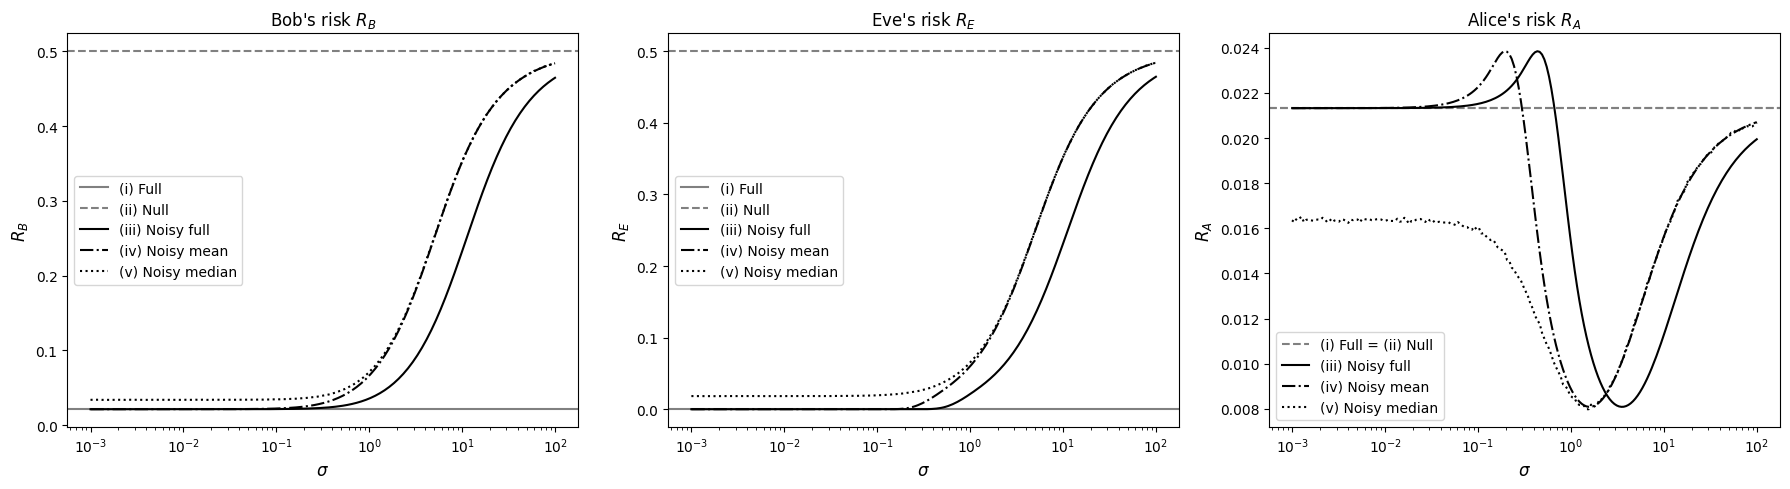

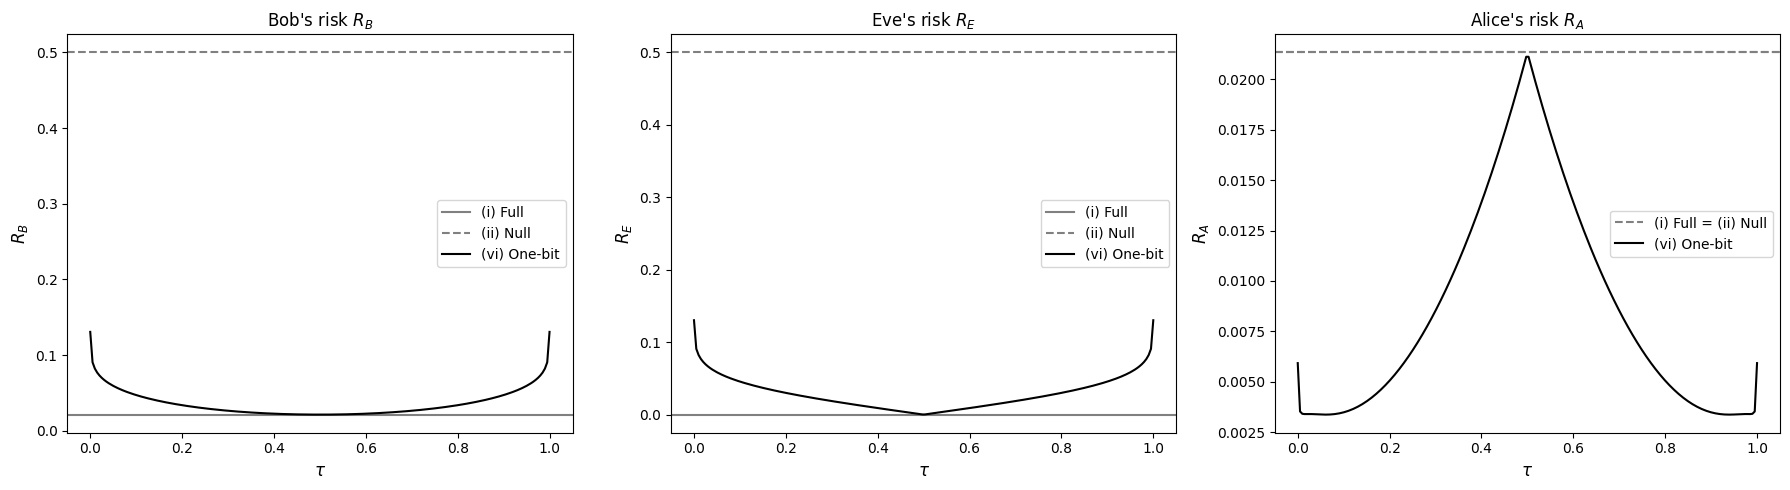

In [88]:
plot_sigma_supplementary(sigmas = sigmas, RB1=RB1_mean, RE1=RE1_mean, RA1=RA1_mean,
           RB2=RB2_mean, RE2=RE2_mean, RA2=RA2_mean,
           RB3s=RB3s_mean, RE3s=RE3s_mean, RA3s=RA3s_mean,
           RB4s=RB4s_mean, RE4s=RE4s_mean, RA4s=RA4s_mean,
           RB5s=RB5s_mean, RE5s=RE5s_mean, RA5s=RA5s_mean, save_name=f"figures/supplementary/plot_sigma_supplementary_mean_sigma0_{sigma0}.pdf")

plot_tau_supplementary(taus = taus, RB1=RB1_mean, RE1=RE1_mean, RA1=RA1_mean,
         RB2=RB2_mean, RE2=RE2_mean, RA2=RA2_mean,
         RB6s=RB6s_mean, RE6s=RE6s_mean, RA6s=RA6s_mean, save_name=f"figures/supplementary/plot_tau_supplementary_mean_sigma0_{sigma0}.pdf")

### Paper

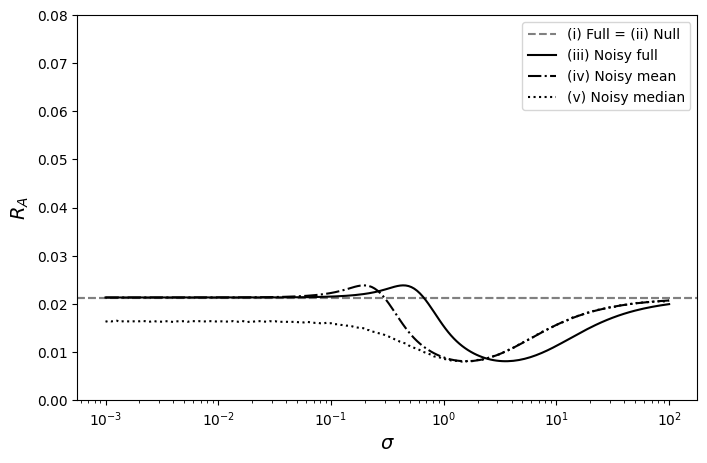

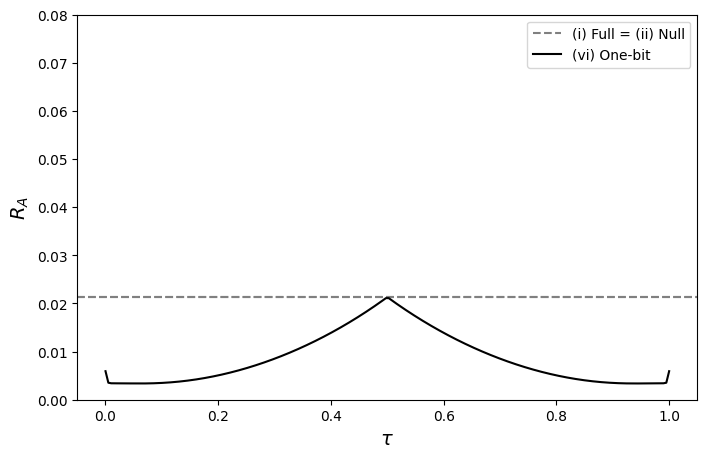

In [89]:
ylim = (0.0, 0.08)
ytick = np.linspace(ylim[0], ylim[1], 9)

plot_sigma_paper(RA1=RA1_mean, RA2=RA2_mean, RA3s=RA3s_mean, RA4s=RA4s_mean, RA5s=RA5s_mean, sigmas=sigmas, save_name=f"figures/paper/plot_sigma_paper_mean_sigma0_{sigma0}.pdf", yticks=ytick, ylim=ylim)

plot_tau_paper(RA1=RA1_mean, RA2=RA2_mean, RA6s=RA6s_mean, taus=taus, save_name=f"figures/paper/plot_tau_paper_mean_sigma0_{sigma0}.pdf", yticks=ytick, ylim=ylim)

## Max

### Supplementary

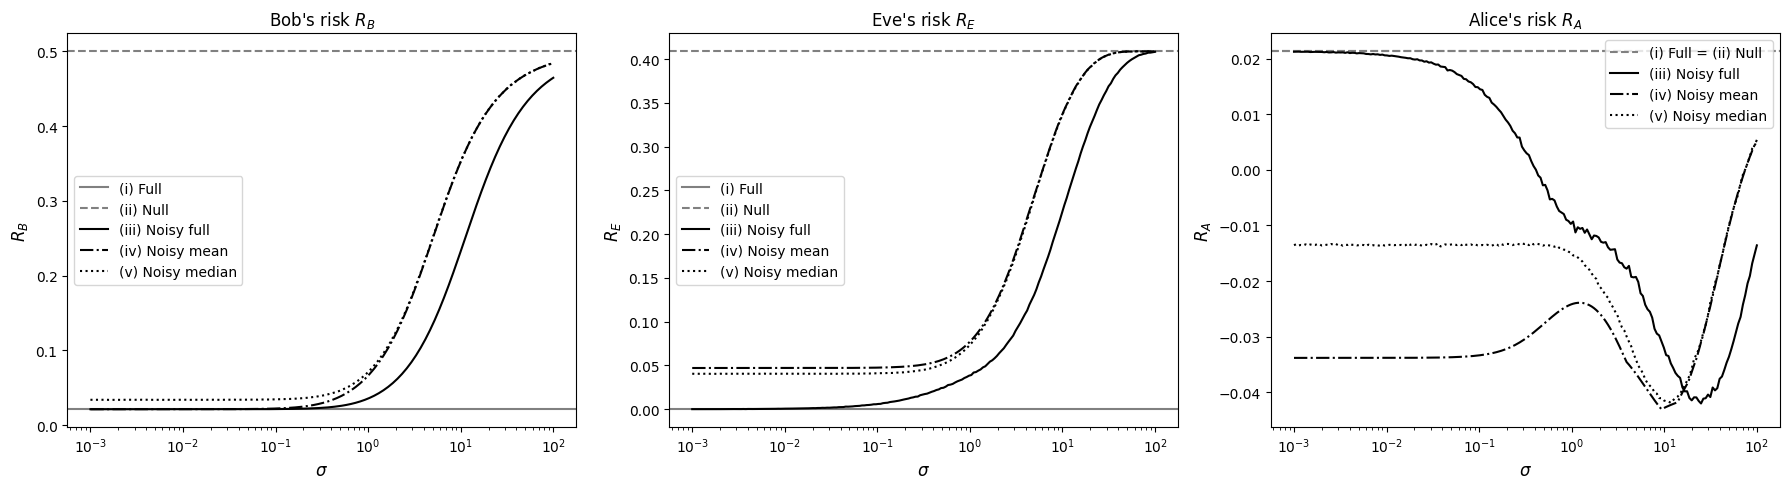

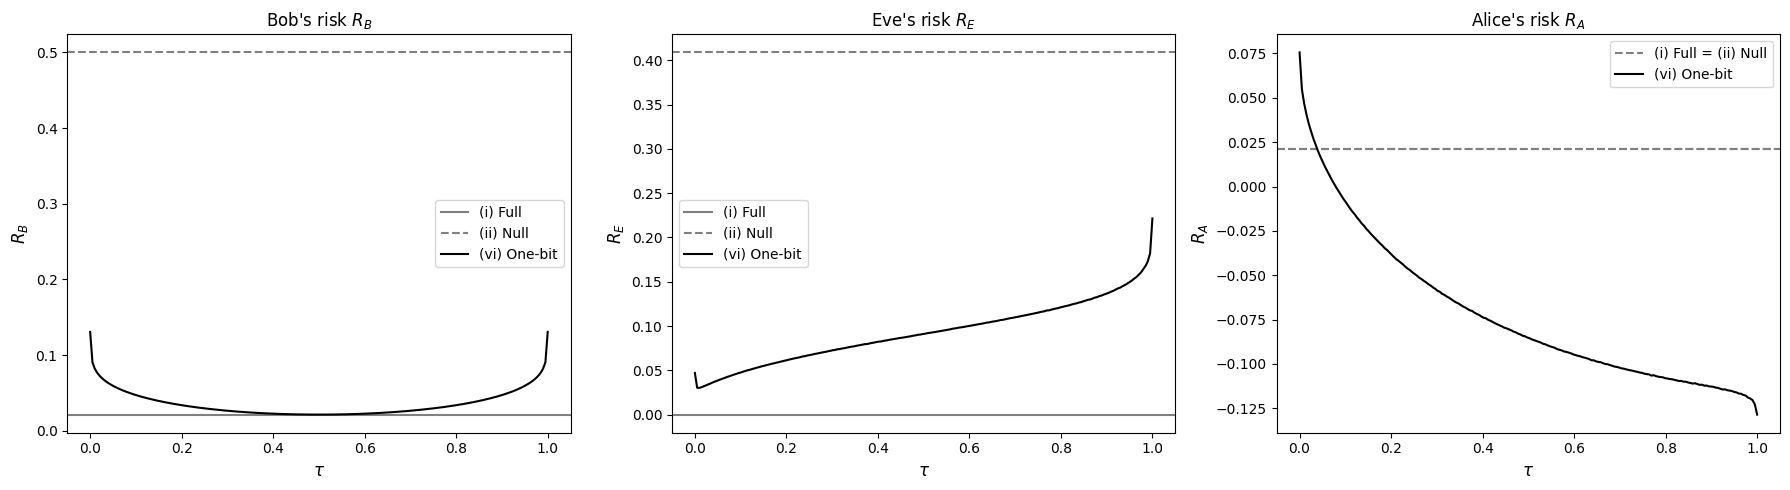

In [90]:
plot_sigma_supplementary(sigmas = sigmas, RB1=RB1_max, RE1=RE1_max, RA1=RA1_max,
           RB2=RB2_max, RE2=RE2_max, RA2=RA2_max,
           RB3s=RB3s_max, RE3s=RE3s_max, RA3s=RA3s_max,
           RB4s=RB4s_max, RE4s=RE4s_max, RA4s=RA4s_max,
           RB5s=RB5s_max, RE5s=RE5s_max, RA5s=RA5s_max, save_name=f"figures/supplementary/plot_sigma_supplementary_max_sigma0_{sigma0}.pdf")

plot_tau_supplementary(taus = taus, RB1=RB1_max, RE1=RE1_max, RA1=RA1_max,
         RB2=RB2_max, RE2=RE2_max, RA2=RA2_max,
         RB6s=RB6s_max, RE6s=RE6s_max, RA6s=RA6s_max, save_name=f"figures/supplementary/plot_tau_supplementary_max_sigma0_{sigma0}.pdf")



### Paper

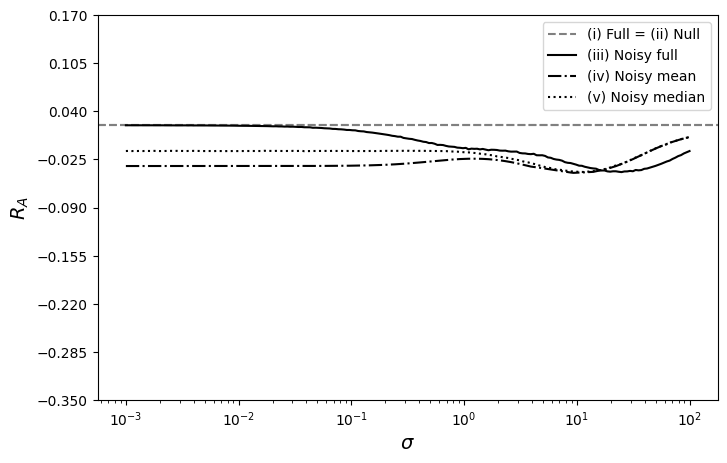

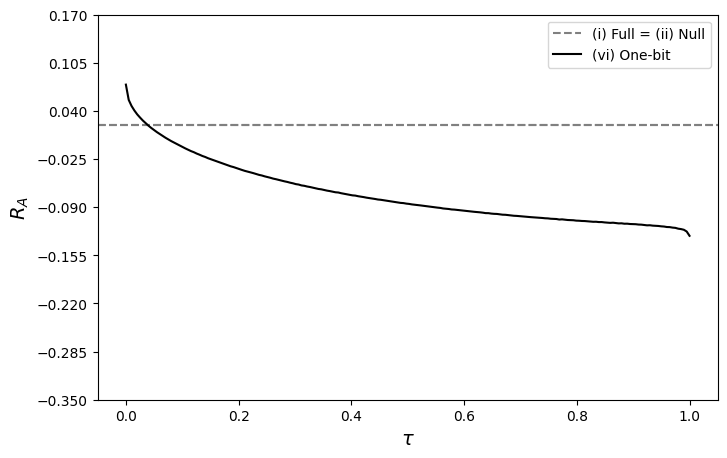

In [91]:
ylim = (-0.35, 0.17)
ytick = np.linspace(ylim[0], ylim[1], 9)

plot_sigma_paper(RA1=RA1_max, RA2=RA2_max, RA3s=RA3s_max, RA4s=RA4s_max, RA5s=RA5s_max, sigmas=sigmas, save_name=f"figures/paper/plot_sigma_paper_max_sigma0_{sigma0}.pdf", yticks=ytick, ylim=ylim)

plot_tau_paper(RA1=RA1_max, RA2=RA2_max, RA6s=RA6s_max, taus=taus, save_name=f"figures/paper/plot_tau_paper_max_sigma0_{sigma0}.pdf", yticks=ytick, ylim=ylim)

## Save table results

In [92]:
def write_gaussian_table_tex(
    RB1: float, RE1: float, RA1: float,
    RB2: float, RE2: float, RA2: float,
    sigmas,
    taus,
    # Case 3
    RB3s, RE3s, RA3s,
    # Case 4
    RB4s, RE4s, RA4s,
    # Case 5
    RB5s, RE5s, RA5s,
    # Case 6
    RB6s, RE6s, RA6s,
    save_name: str,
    decimals: int = 2,
):
    """
    Example 2 (Gaussian): build + print + save LaTeX *tabular rows* (no \\begin{table}).
    Matches the style of Example 1.

    Inputs:
      - Case 1 & 2: scalars RB*, RE*, RA*
      - sigmas, taus: grids
      - Case 3–6: arrays RB*s, RE*s, RA*s aligned with sigmas/taus
      - save_name: output path (e.g. 'tables/comparison_mean.tex')

    Output:
      - returns latex_str (tabular rows)
    """
    # --- arrays
    sigmas = np.asarray(sigmas, dtype=float)
    taus = np.asarray(taus, dtype=float)

    RB3s, RE3s, RA3s = map(lambda x: np.asarray(x, dtype=float), (RB3s, RE3s, RA3s))
    RB4s, RE4s, RA4s = map(lambda x: np.asarray(x, dtype=float), (RB4s, RE4s, RA4s))
    RB5s, RE5s, RA5s = map(lambda x: np.asarray(x, dtype=float), (RB5s, RE5s, RA5s))
    RB6s, RE6s, RA6s = map(lambda x: np.asarray(x, dtype=float), (RB6s, RE6s, RA6s))

    if RA3s.shape != sigmas.shape or RA4s.shape != sigmas.shape or RA5s.shape != sigmas.shape:
        raise ValueError("Case 3–5 arrays must have the same shape as sigmas.")
    if RA6s.shape != taus.shape:
        raise ValueError("Case 6 arrays must have the same shape as taus.")

    # --- optima
    i3 = int(np.argmin(RA3s))
    i4 = int(np.argmin(RA4s))
    i5 = int(np.argmin(RA5s))
    i6 = int(np.argmin(RA6s))

    sigma3, sigma4, sigma5 = sigmas[i3], sigmas[i4], sigmas[i5]
    tau6 = taus[i6]

    # --- formatting
    fmt = lambda x: f"{float(x):.{decimals}f}"

    lines = []
    lines.append(r"Mechanism & $R_B$ & $R_E$ & $R_A$\\")
    lines.append(r"\hline")

    # Case 1–2
    lines.append(rf"Full & {fmt(RB1)} & {fmt(RE1)} & {fmt(RA1)} \\")
    lines.append(rf"Null & {fmt(RB2)} & {fmt(RE2)} & {fmt(RA2)} \\")

    # Case 3–6 (with tuned params)
    lines.append(
        rf"Noisy full ($\sigma^* = {sigma3:.2f}$) & {fmt(RB3s[i3])} & {fmt(RE3s[i3])} & {fmt(RA3s[i3])} \\"
    )
    lines.append(
        rf"Noisy mean ($\sigma^* = {sigma4:.2f}$) & {fmt(RB4s[i4])} & {fmt(RE4s[i4])} & {fmt(RA4s[i4])} \\"
    )
    lines.append(
        rf"Noisy median ($\sigma^* = {sigma5:.2f}$) & {fmt(RB5s[i5])} & {fmt(RE5s[i5])} & {fmt(RA5s[i5])} \\"
    )
    lines.append(
        rf"One-bit ($\tau^* = {tau6:.2f}$) & {fmt(RB6s[i6])} & {fmt(RE6s[i6])} & {fmt(RA6s[i6])}"
    )

    latex_str = "\n".join(lines) + "\n"

    # Print
    print(latex_str)

    # Save
    os.makedirs(os.path.dirname(save_name) or ".", exist_ok=True)
    with open(save_name, "w", encoding="utf-8") as f:
        f.write(latex_str)

    return latex_str

print("MEAN")
_ = write_gaussian_table_tex(RB1_mean, RE1_mean, RA1_mean, RB2_mean, RE2_mean, RA2_mean, sigmas, taus, RB3s_mean, RE3s_mean, RA3s_mean, RB4s_mean, RE4s_mean, RA4s_mean, RB5s_mean, RE5s_mean, RA5s_mean, RB6s_mean, RE6s_mean, RA6s_mean, "tables/gaussian_mean_table.tex")
print("MAX")
_ = write_gaussian_table_tex(RB1_max, RE1_max, RA1_max, RB2_max, RE2_max, RA2_max, sigmas, taus, RB3s_max, RE3s_max, RA3s_max, RB4s_max, RE4s_max, RA4s_max, RB5s_max, RE5s_max, RA5s_max, RB6s_max, RE6s_max, RA6s_max, "tables/gaussian_max_table.tex")

MEAN
Mechanism & $R_B$ & $R_E$ & $R_A$\\
\hline
Full & 0.02 & 0.00 & 0.02 \\
Null & 0.50 & 0.50 & 0.02 \\
Noisy full ($\sigma^* = 3.49$) & 0.10 & 0.09 & 0.01 \\
Noisy mean ($\sigma^* = 1.55$) & 0.10 & 0.09 & 0.01 \\
Noisy median ($\sigma^* = 1.46$) & 0.10 & 0.09 & 0.01 \\
One-bit ($\tau^* = 0.06$) & 0.06 & 0.06 & 0.00

MAX
Mechanism & $R_B$ & $R_E$ & $R_A$\\
\hline
Full & 0.02 & 0.00 & 0.02 \\
Null & 0.50 & 0.41 & 0.02 \\
Noisy full ($\sigma^* = 24.95$) & 0.37 & 0.35 & -0.04 \\
Noisy mean ($\sigma^* = 9.33$) & 0.34 & 0.33 & -0.04 \\
Noisy median ($\sigma^* = 11.76$) & 0.37 & 0.35 & -0.04 \\
One-bit ($\tau^* = 1.00$) & 0.13 & 0.22 & -0.13

